# IMPORT

In [1]:
# Import
import os
def start_workspace():
    curr = os.getcwd()
    while curr != os.path.dirname(curr):
        potential_ini = os.path.join(curr, 'src', 'ini.py')
        if os.path.exists(potential_ini):
            get_ipython().run_line_magic('run', f'-i "{potential_ini}"')
            return True
        curr = os.path.dirname(curr)
    return False

if not start_workspace():
    print("❌ Konnte 'src/ini.py' nicht finden. Prüfe die Ordnerstruktur!")

%load_ext autoreload
%autoreload 2

✅ Universal workspace ready!
📍 Main folder: /Users/cristallagus/Desktop/GitHub/weebet/_onboarding_data
📦 Modules loaded: sql_database_conectors_image, sql_database_upload, clean_data, pre_eda_words, sql_database_offline_download, sql_database_offline_in_df, pre_eda_data, translator, pandas_deepseek_offline_agent


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load csv in df

In [3]:
# DATA LOAD
df = load_data("daily_tasks/day_4/day_4_datasets/sat-results.csv")

In [4]:
df.head(1)

,DBN,SCHOOL NAME,Num of SAT Test Takers,SAT Critical Reading Avg. Score,SAT Math Avg. Score,SAT Writing Avg. Score,SAT Critical Readng Avg. Score,internal_school_id,contact_extension,pct_students_tested,academic_tier_rating
0,01M292,HENRY STREET SCHOOL FOR INTERNATIONAL STUDIES,29,355,404,363,355,218160,x345,78%,2.0


# Explore the Dataset

- Open the CSV and review its structure
- Refer to: daily_tasks/day_4/day_4_datasets/readme.md
- Identify which columns are useful and which are synthetic or dirty


In [5]:
full_data_analysis(df)

********** CONSOLIDATED DATA QUALITY ANALYSIS **********
                                                                                                                        -->  -->  -->  
Shape (Rows, Columns): (493, 11) | Duplicate Rows: 15
--------------------------------------------------
   Datentyp     Semantischer_Typ  Einzigartige_Werte  Kardinalität(%)                           Spalte  Duplicate  NaN  NaN(%)       Min Lower_Fence  25% (Q1)    Median     StdDev  75% (Q3) Upper_Fence Max/100%(Q4) Skewness Ausreißer (IQR) Ausreißer (StdDev)
0    object               object                 478            96.96                              DBN         15    0    0.00         -           -         -         -          -         -           -            -        -               -                  -
1    object      Text (Freitext)                 478            96.96                      SCHOOL NAME         15    0    0.00         -           -         -         -          -     

In [5]:
df= clean_type_stochastic_flote_int(df)

✅ Stochastic Type-Sync complete.
📊 Anzahl der NaN Werte (ehemals 's' oder leer) in Zahlen-Spalten:
Num of SAT Test Takers              58
SAT Critical Reading Avg. Score     58
SAT Math Avg. Score                 58
SAT Writing Avg. Score              58
SAT Critical Readng Avg. Score      58
pct_students_tested                117
academic_tier_rating                91
dtype: int64


In [7]:
full_words_analysis(df)

🚀 STARTING FULL COMPARISON ANALYSIS (4 Columns)
📊 1. STRUCTURE & QUALITY


,NaNs,Unique,Kardinalität %,Dom. Sprache,Sonderzeichen
Spalte,,,,,
DBN,0,478,97.0,N/A,1
SCHOOL NAME,0,478,97.0,de,53
internal_school_id,0,478,97.0,N/A,0
contact_extension,105,3,0.6,N/A,0


🧠 2. CONTENT & SEMANTIC DEPTH


,Lex. Diversity,Stopword-Last,Top 5 Tokens,Zahlen im Text
Spalte,,,,
DBN,1.00,0.00,"02m520, 05m304, 07x221, 13k605, 27q480",493
SCHOOL NAME,1.00,0.11,"school, high, for, academy, and",11
internal_school_id,1.00,0.00,"892839, 296405, 277389, 937579, 863765",493
contact_extension,0.79,0.00,"x345, x234, x123",388


📏 3. LENGTH STATISTICS (RAW DATA)


,Ø Zeichen,Max Zeichen,Ø Wörter,Max Wörter
Spalte,,,,
DBN,6.0,13,1.0,1
SCHOOL NAME,36.6,79,5.5,12
internal_school_id,6.0,6,1.0,1
contact_extension,3.1,4,0.8,1


⚠️ 4. ANOMALY BOARD (MANCOS)


,Leere Texte,Short (<5),Emojis,Shortforms,Shouting,Duplikate
Spalte,,,,,,
DBN,0,0,0,0,1,15
SCHOOL NAME,0,0,1,4,483,15
internal_school_id,0,0,0,0,0,15
contact_extension,105,493,0,0,0,489


# Clean the Data Using Python

- Handle duplicates, invalid SAT scores, and inconsistent formatting (e.g., "85%"), weird outliers and any inconsistencies (hint: valid scores are between 200 and 800)
Normalize headers and drop unrelated fields

In [6]:
# Step 0: Remove redundant columns with typos
# We keep the correct column and delete the one with the typo 'Readng'

redundant_cols = ['SAT Critical Readng Avg. Score']

# We check if the column exists and then drop it
df = df.drop(columns=[col for col in redundant_cols if col in df.columns])

print("✅ Redundant column 'SAT Critical Readng Avg. Score' has been removed.")

✅ Redundant column 'SAT Critical Readng Avg. Score' has been removed.


In [7]:
# Step 1: Normalize column titles
# We trim whitespace, convert to lowercase, and replace spaces/dots with underscores
df = clean_column_names(df)

✅ Neue Spalten-Titel für SQL: ['dbn', 'school_name', 'num_of_sat_test_takers', 'sat_critical_reading_avg_score', 'sat_math_avg_score', 'sat_writing_avg_score', 'internal_school_id', 'contact_extension', 'pct_students_tested', 'academic_tier_rating']


In [8]:
# Step 2: Convert 's' and empty values to NaN & fix data types

# 1. List of columns (normalized names)
numeric_cols = [
    'num_of_sat_test_takers', 
    'sat_critical_reading_avg_score', 
    'sat_math_avg_score', 
    'sat_writing_avg_score',
    'pct_students_tested',
    'academic_tier_rating'
]
for col in numeric_cols:
    if col in df.columns:
        # If it's a string column, remove % signs (for pct_students_tested)
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace('%', '', regex=False)
        # Conversion: non-numeric values (like 's') become NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')

print("Number of NaN values after conversion:")
print(df[numeric_cols].isna().sum())

Number of NaN values after conversion:
num_of_sat_test_takers             58
sat_critical_reading_avg_score     58
sat_math_avg_score                 58
sat_writing_avg_score              58
pct_students_tested               117
academic_tier_rating               91
dtype: int64


In [9]:
# Step 3: Remove duplicates (Only if the entire row is identical)
df = clean_rows_remove_duplicates(df)

✅ Duplikate entfernt: 15


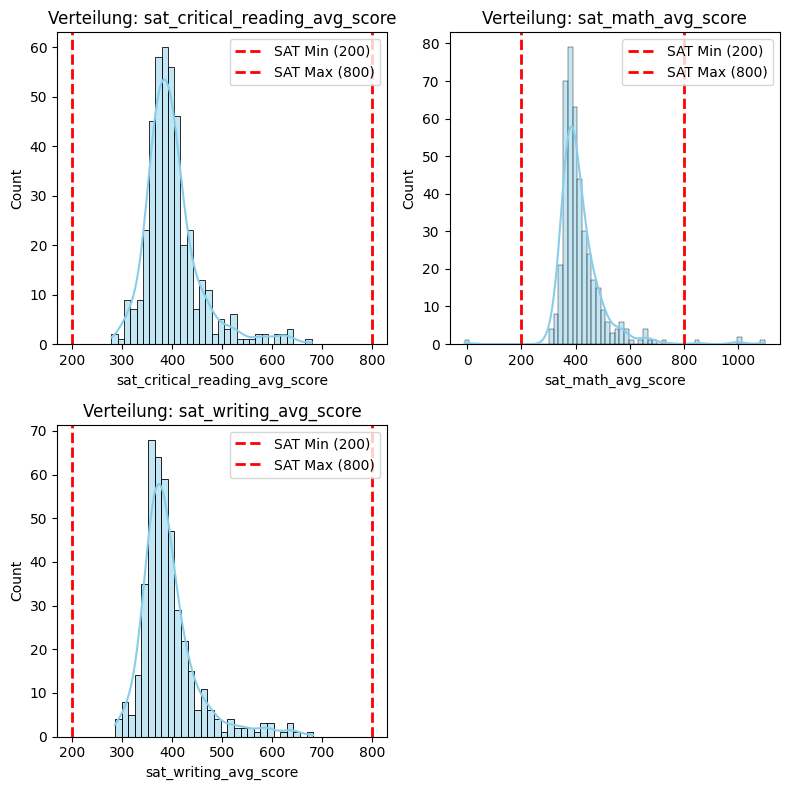

💡 Interpretation: Alle Datenpunkte LINKS von der ersten roten Linie oder RECHTS von der zweiten
   sind fachlich unmöglich und müssen bereinigt werden.


In [ ]:
# Identify the 4 relevant score columns

# Only include columns that have 'score' in their name AND actually exist in the df
score_cols = [col for col in df.columns if 'score' in col.lower()]

# Dynamic layout based on the number of columns found
num_plots = len(score_cols)
cols = 2
rows = (num_plots + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(8, 4 * rows))
axes = axes.flatten()

for i, col in enumerate(score_cols):
    # Histogram plot
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='skyblue')
    
    # Domain-specific SAT boundaries (Min 200, Max 800)
    axes[i].axvline(200, color='red', linestyle='--', linewidth=2, label='SAT Min (200)')
    axes[i].axvline(800, color='red', linestyle='--', linewidth=2, label='SAT Max (800)')
    
    axes[i].set_title(f"Distribution: {col}")
    axes[i].legend()

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

print("💡 Interpretation: All data points LEFT of the first red line or RIGHT of the second")
print("   are technically impossible and must be cleaned.")

In [10]:
# STEP 4: Domain-specific outlier cleaning (SAT Scores 200-800)
# We use stochastic detection for all score columns

# 1. Identify all columns containing scores (stochastically via name)
score_cols = [col for col in df.columns if 'score' in col.lower()]

for col in score_cols:
    # Count outliers before cleaning for the log
    outliers = df[(df[col] < 200) | (df[col] > 800)][col].count()
    
    if outliers > 0:
        # Domain-specific correction: Values outside the [200, 800] range are set to NaN
        df.loc[(df[col] < 200) | (df[col] > 800), col] = np.nan
        print(f"⚠️ Column '{col}': {outliers} invalid values (outside 200-800) set to NaN.")

# 2. Brief check of the new extreme values
print("\n✅ Validation complete. New boundary values:")
print(df[score_cols].agg(['min', 'max']))

⚠️ Column 'sat_math_avg_score': 5 invalid values (outside 200-800) set to NaN.

✅ Validation complete. New boundary values:
     sat_critical_reading_avg_score  sat_math_avg_score  sat_writing_avg_score
min                           279.0               312.0                  286.0
max                           679.0               735.0                  682.0


Unterer Cut (200): Ein Score von -10.0 ist technisch unmöglich; da das offizielle Minimum bei 200 liegt, verfälschen solche negativen Ausreißer den Mittelwert und müssen entfernt werden.

Oberer Cut (800): Ein Maximalwert von 1100.0 überschreitet das Punktemaximum von 800 und ist zweifelsfrei als Eingabefehler zu klassifizieren.

Statistischer Vergleich: Da die statistischen Grenzwerte (Upper Fences) der Daten zwischen 488.0 und 537.0, stellt ein Cut bei 800 keinen Datenverlust, dient rein als notwendige Schutzschranke.

# Design the Schema
- Choose columns to upload to the database

- Datenbank-Quelle: Der Prozess nutzt gezielt das Schema nyc_schools als isolierten Container Bildungsdaten.

- Master-Tabelle: Die Tabelle schools (oder schools_directory) fungiert als zentraler Anker für alle Stammdaten.

- Verbindungs-ID: Die Verknüpfung erfolgt über die Spalte dbn (District Borough Number), da diese als eindeutiger Identifikator (Primary Key).

- Metadaten-Synchronisation: Über die dbn werden die numerischen SAT-Ergebnisse automatisch mit geografischen Koordinaten, offiziellen Schulnamen und administrativen Bezirkszuordnungen des Gesamtmodells verbunden.

In [ ]:
# SAVE TABLE
# 1. Define the target directory (as per task instructions: 'day_4_task')
output_dir = "day_4_task"

# 2. Create the directory if it doesn't exist yet
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"✅ Directory '{output_dir}' has been created.")

# 3. Save the CSV file into this directory
output_path = os.path.join(output_dir, "cleaned_sat_results.csv")
df.to_csv(output_path, index=False)

print(f"✅ File successfully saved at: {output_path}")

✅ Ordner 'day_4_task' wurde erstellt.
✅ Datei erfolgreich gespeichert unter: day_4_task/cleaned_sat_results.csv


In [ ]:
# APPEND SQL DATA FROM LINK

from sqlalchemy import create_engine, text

# 1. Establish database connection (Read plain text from file)
# We use open() because load_data() incorrectly interprets the URL as a DataFrame
with open("src/SQL_LINK_.txt", "r") as f:
    db_link = f.read().strip()

# Create the engine using the cleaned string
engine = create_engine(db_link)

# 2. Define the complete SQL setup in a string
# Adjusted table name to meet the task requirement: [your-name]_sat_results
sql_setup = """
CREATE SCHEMA IF NOT EXISTS nyc_schools;

CREATE TABLE IF NOT EXISTS nyc_schools.agus_sat_results (
    dbn VARCHAR(10) PRIMARY KEY,
    school_name TEXT,
    num_of_sat_test_takers INTEGER,
    sat_critical_reading_avg_score INTEGER,
    sat_math_avg_score INTEGER,
    sat_writing_avg_score INTEGER,
    pct_students_tested NUMERIC(5,2),
    academic_tier_rating INTEGER,
    internal_school_id VARCHAR(20),
    contact_extension VARCHAR(10)
);
"""

# 3. Prepare infrastructure on the database
with engine.connect() as conn:
    conn.execute(text(sql_setup))
    conn.commit()
    print("✅ Infrastructure ready: Schema 'nyc_schools' and table 'agus_sat_results' have been created.")

# 4. Data Upload (Append logic)
# Loads the cleaned DataFrame into the prepared "drawer"
df.to_sql(
    name='agus_sat_results', 
    con=engine, 
    schema='nyc_schools', 
    if_exists='append', 
    index=False
)

# 5. Export cleaned data to CSV (Requirement for submission)
df.to_csv("day_4_task/cleaned_sat_results.csv", index=False)

print(f"✅ Data upload complete: {len(df)} rows successfully transferred to nyc_schools.agus_sat_results.")
print("✅ Cleaned dataset exported to 'day_4_task/cleaned_sat_results.csv'.")

# Write a Python Script to Append Data

Use psycopg2 or sqlalchemy to connect
Append cleaned data to your [your-name]_sat_scores table in nyc_schools schema
Use parameterized queries and commit logic